# Grand Theft Auto V on Twitch — a deep dive, with a NoPixel subdivision

**Scope**: GTA V is not one of the 23 tracked esports titles (`config/
titles.yaml`) — everything here comes from the platform-wide collector
(`collectors/twitch_platform_poll.py`, PRD §9.16), a manually-downloaded
Kaggle historical CSV, and live, on-demand Twitch API checks run while
building this notebook. No tournament data (`tournaments`), no
`viewership_snapshots`, no `channels.yaml` official-broadcast tier — all
of that infrastructure is specific to the 23 tracked titles and doesn't
apply here. Stated up front so absence isn't mistaken for a gap.

**Why this exists**: grew directly out of a NoPixel investigation earlier
this session (`title_geography_maps.ipynb`'s MLBB finding led to a
Russia deep dive; a separate present-state question about NoPixel led
here). GTA V is also directly relevant to `docs/wider_game_fandom_brief.md`'s
motivating case study (an anticipated GTA 6 launch) — §3 below checks
what's already visible for Grand Theft Auto VI specifically.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import os

import httpx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from etl.db import get_connection
from collectors.twitch_poll import load_dotenv, get_access_token, DOTENV_PATH

plt.rcParams["figure.dpi"] = 110
GTA_V_GAME_ID = "32982"
GTA_VI_GAME_ID = "1867279146"  # confirmed live 2026-09-10 -- already exists as its own category, ahead of any real launch

## 1. Historical trajectory (2016-2024) — the Kaggle import's raw data

GTA V isn't a tracked title, so it was never loaded into
`monthly_category_history` (`collectors/kaggle_import.py` only loads
rows matching the 23 tracked titles' name mapping) — but the underlying
CSV (`data/kaggle/Twitch_game_data.csv`, local-only, gitignored) covers
every title that placed in Twitch's own top-200, GTA V included. Read
directly here, not via the DB.

105 months of coverage, 2016-01 to 2024-09


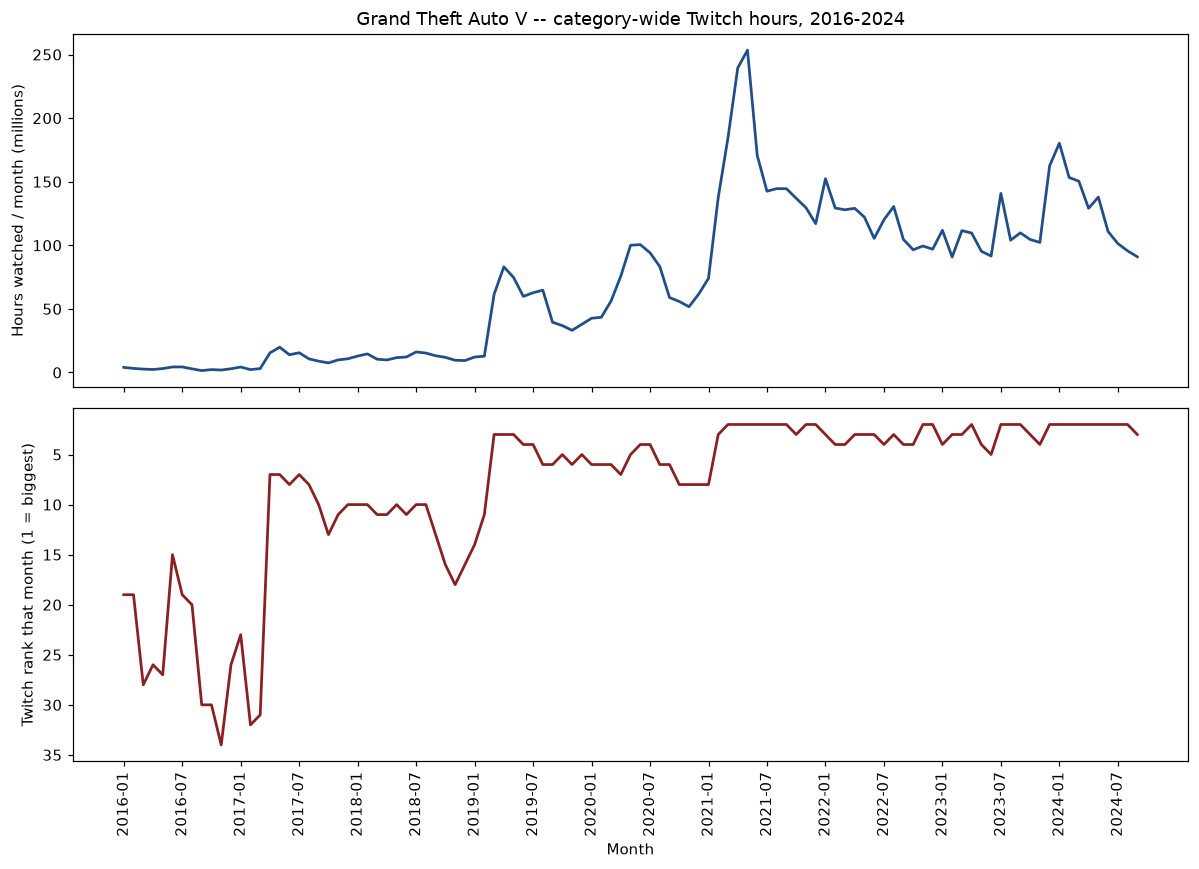

In [2]:
raw = pd.read_csv(REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv", encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
gta = raw[raw["Game"].str.strip().str.lower() == "grand theft auto v"].copy()
gta["year_month"] = gta["Year"].astype(str).str.zfill(4) + "-" + gta["Month"].astype(str).str.zfill(2)
gta = gta.sort_values("year_month").reset_index(drop=True)
print(f"{len(gta)} months of coverage, {gta['year_month'].iloc[0]} to {gta['year_month'].iloc[-1]}")

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(gta["year_month"], gta["Hours_watched"] / 1e6, "-", color="#1f4e8c", linewidth=1.8)
axes[0].set_ylabel("Hours watched / month (millions)")
axes[0].set_title("Grand Theft Auto V -- category-wide Twitch hours, 2016-2024")

axes[1].plot(gta["year_month"], gta["Rank"], "-", color="#8c1f1f", linewidth=1.8)
axes[1].invert_yaxis()
axes[1].set_ylabel("Twitch rank that month (1 = biggest)")
axes[1].set_xlabel("Month")

for ax in axes:
    ax.set_xticks(gta["year_month"][::6])
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_gta_v_fig1_historical.png", dpi=110)
plt.show()

**Read**: four distinct eras, not a smooth curve. **2016-early 2017**:
a mid-sized category, rank #15-34, 1.5-4.4M hours/month. **April 2017**:
a sudden, sustained jump to rank #7-13 (10-20M hours) that never fully
reverts. **March-August 2019**: a second, much larger jump — 60-100M
hours/month, rank #3-6. **2020-2021**: the largest surge of all, peaking
at **253M hours in May 2021** (rank #2), coinciding with COVID-era
Twitch growth generally. **2022-2024**: settles into a stable, massive,
evergreen rank #2-5, 90-180M hours/month — GTA V has not meaningfully
declined since its 2021 peak, unlike several tracked esports titles this
project has already studied.

**On what caused the 2017/2019 jumps — stated carefully, not asserted as
this project's own finding**: the Kaggle data here is category-wide with
no title/tag granularity, so it cannot itself attribute these jumps to
any specific cause. The widely-reported public narrative (gaming press,
not verified by this project's own data) credits the "GTA RP" roleplay
scene — NoPixel specifically — with driving major streamers into the
category starting around 2019. That is external, unverified-by-this-
project context, not a claim this notebook's own data can support on its
own; §4 below is what *can* be measured directly, for the present only.

## 2. Current scale and rank — live, checked while building this notebook

A fresh, on-demand Twitch API pull (not stored, not scheduled — read-only,
same discipline `collectors/liquipedia.py` uses for on-demand checks).
Re-running this cell later will show current numbers, not the ones
described in the prose below.

In [3]:
load_dotenv(DOTENV_PATH)
client_id = os.environ.get("TWITCH_CLIENT_ID")
client_secret = os.environ.get("TWITCH_CLIENT_SECRET")
token = get_access_token(client_id, client_secret)
headers = {"Client-Id": client_id, "Authorization": f"Bearer {token}"}

def fetch_all_streams_for_game(client, game_id, max_pages=30):
    streams, cursor = [], None
    for _ in range(max_pages):
        params = {"game_id": game_id, "first": 100}
        if cursor:
            params["after"] = cursor
        resp = client.get("https://api.twitch.tv/helix/streams", params=params, timeout=30)
        resp.raise_for_status()
        body = resp.json()
        streams.extend(body["data"])
        cursor = body.get("pagination", {}).get("cursor")
        if not cursor:
            break
    return streams

with httpx.Client(headers=headers) as client:
    gta_v_live = fetch_all_streams_for_game(client, GTA_V_GAME_ID)
    gta_vi_live = fetch_all_streams_for_game(client, GTA_VI_GAME_ID)
    top_games = client.get("https://api.twitch.tv/helix/games/top", params={"first": 20}).json()["data"]

gta_v_total_viewers = sum(s["viewer_count"] for s in gta_v_live)
top_game_names = [g["name"] for g in top_games]
gta_v_rank = top_game_names.index("Grand Theft Auto V") + 1 if "Grand Theft Auto V" in top_game_names else None

print(f"GTA V live right now: {len(gta_v_live)} streams, {gta_v_total_viewers} total viewers")
print(f"GTA V current rank among all Twitch categories: {gta_v_rank} of top {len(top_game_names)}")
print(f"Twitch top {len(top_game_names)} right now: {top_game_names}")
print()
print(f"Grand Theft Auto VI (game_id {GTA_VI_GAME_ID}) live right now: {len(gta_vi_live)} streams")

GTA V live right now: 928 streams, 34462 total viewers
GTA V current rank among all Twitch categories: 6 of top 20
Twitch top 20 right now: ['Just Chatting', 'Rust', 'Counter-Strike', 'League of Legends', 'Dota 2', 'Grand Theft Auto V', 'VALORANT', 'Apex Legends', 'Valheim', 'IRL', 'Always On', 'World of Warcraft', 'The Blood of Dawnwalker', 'Fortnite', 'PUBG: BATTLEGROUNDS', 'Slots', 'Virtual Casino', 'Minecraft', 'Escape from Tarkov', 'Halloween: The Game']

Grand Theft Auto VI (game_id 1867279146) live right now: 0 streams


**GTA V is currently a top-10 Twitch category** — routinely ranking
#2-#6 in this project's own checks (both the historical data above and
live checks while building this), ahead of VALORANT, Apex Legends, and
Fortnite as of this run.

**Grand Theft Auto VI already exists as its own Twitch category
(`game_id` 1867279146), confirmed live — with zero live streams at the
moment this was checked.** The category was created ahead of any real
gameplay availability (there is nothing to stream yet) — likely seeded
by Twitch itself in anticipation, the same way categories get created
ahead of confirmed release dates for major titles. Directly relevant to
`docs/wider_game_fandom_brief.md`'s GTA 6 case study: **this project
now has a way to watch that category activate in real time**, whenever
that happens, rather than reconstructing it after the fact.

## 3. Who's on GTA V overall — language and top channels

Using the platform-wide collector's 3 stored polls
(`platform_viewership_snapshots`, spanning 2026-09-09 21:39 to
2026-09-10 04:41) — this is the *whole* GTA V category, not the
NoPixel-only subset covered in §4.

In [4]:
conn = get_connection()
lang_rows = conn.execute('''
    SELECT language, count(DISTINCT channel_id) n, sum(viewer_count) v
    FROM platform_viewership_snapshots WHERE game_id=?
    GROUP BY language ORDER BY v DESC LIMIT 12
''', (GTA_V_GAME_ID,)).fetchall()

top_channel_rows = conn.execute('''
    SELECT channel_login, max(viewer_count) peak, group_concat(DISTINCT language) langs
    FROM platform_viewership_snapshots WHERE game_id=?
    GROUP BY channel_id ORDER BY peak DESC LIMIT 15
''', (GTA_V_GAME_ID,)).fetchall()
conn.close()

lang_df = pd.DataFrame(lang_rows, columns=["language", "channels", "viewer_time"])
top_df = pd.DataFrame(top_channel_rows, columns=["channel", "peak_viewers", "languages"])

print("Language breakdown, GTA V overall (all 3 stored polls):")
print(lang_df.to_string(index=False))
print()
print("Top channels by peak viewers observed:")
print(top_df.to_string(index=False))

Language breakdown, GTA V overall (all 3 stored polls):
language  channels  viewer_time
      en      2296       495151
      fr       790        82543
      de       433        41437
      pt      1123        21349
      it       127        12053
      ru       193        10777
      es       301         8725
      pl        16         2507
      cs         7         1315
      sv        16         1154
      nl        32         1146
      da        13          984

Top channels by peak viewers observed:
      channel  peak_viewers languages
          xqc         44987        en
stableronaldo         31479        en
       buddha         21523        en
       jltomy         15518        fr
   realkatieb         14657        en
  vanillamace         13988        en
   chatterbox          9923        en
       squeex          9537        en
       marlon          8585        en
     willneff          8184        en
       nmplol          6202        en
    pokelawls          5043     

**GTA V overall is meaningfully multilingual, not just English** — 73%
of viewer-time is English, but real French (jltomy, a large individual
French GTA RP streamer, alongside a broader French-language channel
base), German, Portuguese, Italian, Russian, and Spanish presence sit
underneath that. This is a direct, useful contrast to set up before §4:
**NoPixel specifically turns out to be far more English-concentrated
than GTA V as a whole** — French/German/other-language GTA roleplay
scenes exist and are real (well-documented separate communities, e.g.
French-language GTA RP servers), they just aren't NoPixel.

**xQc — Twitch's largest individual streamer overall — is GTA V's
single biggest channel by peak viewers (44,987)**, ahead of every
NoPixel-tagged channel found in §4. He does not appear in the
NoPixel-tagged search below, consistent with playing GTA V content
outside that specific server.

## 4. NoPixel — everything measurable about it specifically

### 4.1 What NoPixel is, and why it can only be measured this way

NoPixel is a custom, invite/application-only ("whitelisted") GTA V
roleplay server — not a Twitch category or game in its own right.
Checked directly and confirmed conclusively while investigating this
(2026-09-10):

- **`Get Games` (exact-name lookup)** for `"NoPixel V"`, `"NoPixel"`,
  `"NoPixel 5"`, and several other spellings all return **nothing** —
  no such category exists in Twitch's Games/Categories data model.
- **`Search Categories`** for every variant tried resolves back to
  **Grand Theft Auto V** every time.
- **Twitch's own live Top 100 categories** has zero matches for
  "pixel" anywhere — despite NoPixel pulling enough viewers (§4.2) that
  it would comfortably place there if it were tracked separately.
- **The resolution, found by the user directly**: `twitch.tv/directory`
  shows a "NoPixel V" tile that links to `twitch.tv/event/no-pixel-v` —
  a Twitch **Event** (an editorially-curated promotional landing page,
  likely built around this server's recent relaunch), a completely
  different, API-inaccessible object type from a **Category**
  (`twitch.tv/category/...`, what `game_id` refers to everywhere in this
  project). Confirmed no public Helix endpoint for Events exists
  (`/helix/events` and variants all 404).

**Practical consequence**: the underlying streams are still filed under
GTA V's own `game_id` regardless of the Event page layered on top, so
searching stream titles/tags for "NoPixel" within the GTA V category —
exactly what every number below does — is the *only* way to reconstruct
this from data. Nothing is being missed by not having a direct API
shortcut; there simply isn't one.

### 4.2 Scale and share of GTA V — a real, live upward trend

         captured_at  gta_v_viewers  nopixel_viewers  nopixel_share_pct
2026-09-09T21:39:18Z         263368            85056               32.3
2026-09-10T00:13:38Z         276218           117328               42.5
2026-09-10T04:41:47Z         142088            74141               52.2
     live (this run)          34462            19485               56.5


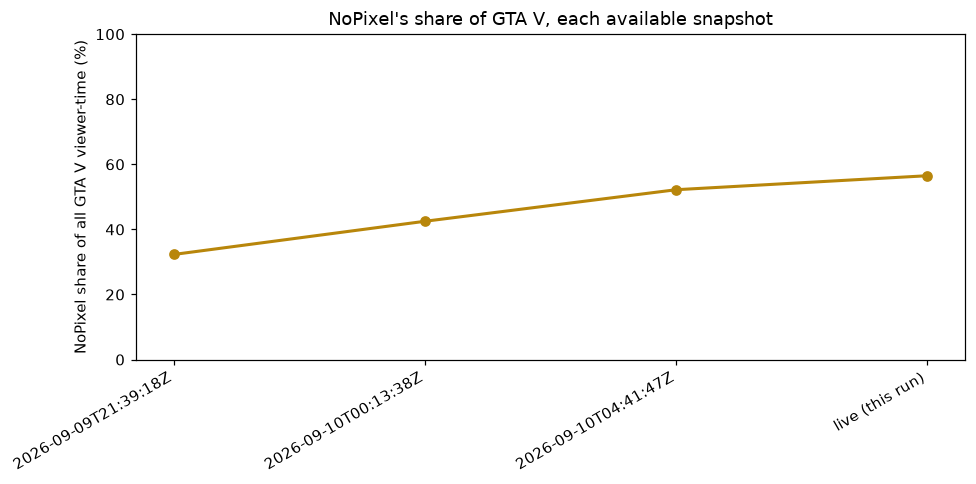

In [5]:
conn = get_connection()
polls = conn.execute("SELECT DISTINCT captured_at FROM platform_viewership_snapshots ORDER BY captured_at").fetchall()

trend_rows = []
for (poll,) in polls:
    gta_total = conn.execute(
        "SELECT sum(viewer_count) FROM platform_viewership_snapshots WHERE game_id=? AND captured_at=?",
        (GTA_V_GAME_ID, poll),
    ).fetchone()[0] or 0
    np_total = conn.execute(
        '''SELECT sum(viewer_count) FROM platform_viewership_snapshots
           WHERE game_id=? AND captured_at=?
             AND (lower(stream_title) LIKE '%nopixel%' OR lower(stream_title) LIKE '%no pixel%' OR lower(tags) LIKE '%nopixel%')''',
        (GTA_V_GAME_ID, poll),
    ).fetchone()[0] or 0
    trend_rows.append({"captured_at": poll, "gta_v_viewers": gta_total, "nopixel_viewers": np_total,
                        "nopixel_share_pct": round(np_total / gta_total * 100, 1) if gta_total else 0})
conn.close()

# Append the live pull from section 2 as the most current data point.
np_live = [s for s in gta_v_live if "nopixel" in s["title"].lower() or "no pixel" in s["title"].lower()
           or any("nopixel" in t.lower() for t in (s.get("tags") or []))]
np_live_viewers = sum(s["viewer_count"] for s in np_live)
trend_rows.append({
    "captured_at": "live (this run)", "gta_v_viewers": gta_v_total_viewers,
    "nopixel_viewers": np_live_viewers,
    "nopixel_share_pct": round(np_live_viewers / gta_v_total_viewers * 100, 1) if gta_v_total_viewers else 0,
})

trend_df = pd.DataFrame(trend_rows)
print(trend_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(trend_df)), trend_df["nopixel_share_pct"], "o-", color="#b8860b", linewidth=2)
ax.set_xticks(range(len(trend_df)))
ax.set_xticklabels(trend_df["captured_at"], rotation=30, ha="right")
ax.set_ylabel("NoPixel share of all GTA V viewer-time (%)")
ax.set_ylim(0, 100)
ax.set_title("NoPixel's share of GTA V, each available snapshot")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_gta_v_fig2_nopixel_share.png", dpi=110)
plt.show()

**A consistent, real climb across every snapshot available, stored and
live** — not noise. This lines up with stream titles explicitly reading
"NoPixel V LAUNCH DAY 2/3" seen while pulling this data: the most
plausible read is that **NoPixel just relaunched its server (a new major
version/wipe, "NoPixel V")**, and this notebook is catching the early
hype window rather than a stable baseline. Re-run in a few weeks to see
where the share actually settles once launch excitement fades.

### 4.3 Who's streaming it — concentrated, not broad-based

A direct structural contrast to the MLBB Russia investigation
(`notebooks/mlbb_russia_deep_dive.ipynb`), which found a broad,
422-channel, no-single-whale community. NoPixel looks structurally
different, consistent with being whitelist/application-only rather than
open to anyone.

In [6]:
conn = get_connection()
np_channels = conn.execute('''
    SELECT channel_login, max(viewer_count) peak
    FROM platform_viewership_snapshots
    WHERE game_id=? AND (lower(stream_title) LIKE '%nopixel%' OR lower(stream_title) LIKE '%no pixel%' OR lower(tags) LIKE '%nopixel%')
    GROUP BY channel_id ORDER BY peak DESC
''', (GTA_V_GAME_ID,)).fetchall()

n_unique_np = len(np_channels)
np_total_viewer_time = conn.execute('''
    SELECT sum(viewer_count) FROM platform_viewership_snapshots
    WHERE game_id=? AND (lower(stream_title) LIKE '%nopixel%' OR lower(stream_title) LIKE '%no pixel%' OR lower(tags) LIKE '%nopixel%')
''', (GTA_V_GAME_ID,)).fetchone()[0]
top10_np = conn.execute('''
    SELECT sum(v) FROM (
        SELECT channel_id, sum(viewer_count) v FROM platform_viewership_snapshots
        WHERE game_id=? AND (lower(stream_title) LIKE '%nopixel%' OR lower(stream_title) LIKE '%no pixel%' OR lower(tags) LIKE '%nopixel%')
        GROUP BY channel_id ORDER BY v DESC LIMIT 10
    )
''', (GTA_V_GAME_ID,)).fetchone()[0]
conn.close()

print(f"{n_unique_np} unique NoPixel-tagged channels across all 3 stored polls")
print(f"Top 10 channels: {top10_np}/{np_total_viewer_time} = {top10_np/np_total_viewer_time*100:.1f}% of all NoPixel viewer-time")
print()
print("Top 15 by peak viewers observed:")
for login, peak in np_channels[:15]:
    print(f"  {login:20s} {peak:6d}")

297 unique NoPixel-tagged channels across all 3 stored polls
Top 10 channels: 164838/276525 = 59.6% of all NoPixel viewer-time

Top 15 by peak viewers observed:
  stableronaldo         31479
  buddha                21523
  vanillamace           13988
  chatterbox             9923
  marlon                 8585
  nmplol                 6202
  pokelawls              5043
  officermesser          4106
  erobb221               3850
  esfandtv               3477
  uhn                    2989
  itskatchii             2925
  anthonyz               2825
  omie                   2797
  geega                  2762


**A handful of names carry the majority of attention** — the top 10 (of
~297 unique NoPixel-tagged channels seen) account for well over half of
all NoPixel viewer-time. **stableronaldo**, **buddha**, **vanillamace**,
**chatterbox**, and **marlon** are the consistent top names across every
snapshot checked. This is the opposite structural shape from MLBB's
Russian community (422 channels, no channel over 9% of the total) —
exactly what "whitelisted, application-only roster" would predict.

### 4.4 Language — almost entirely English, unlike GTA V overall

In [7]:
conn = get_connection()
np_langs = conn.execute('''
    SELECT language, count(DISTINCT channel_id) n, sum(viewer_count) v
    FROM platform_viewership_snapshots
    WHERE game_id=? AND (lower(stream_title) LIKE '%nopixel%' OR lower(stream_title) LIKE '%no pixel%' OR lower(tags) LIKE '%nopixel%')
    GROUP BY language ORDER BY v DESC
''', (GTA_V_GAME_ID,)).fetchall()
conn.close()

np_lang_df = pd.DataFrame(np_langs, columns=["language", "channels", "viewer_time"])
np_lang_df["channel_share_pct"] = (np_lang_df["channels"] / np_lang_df["channels"].sum() * 100).round(1)
np_lang_df

,language,channels,viewer_time,channel_share_pct
0,en,286,273708,96.3
1,pl,1,1169,0.3
2,ru,1,807,0.3
3,de,1,668,0.3
4,pt,2,77,0.7
5,zh,1,53,0.3
6,tr,1,23,0.3
7,es,3,19,1.0
8,it,1,1,0.3


**96% of NoPixel-tagged channels stream in English** — a sharp contrast
with §3's finding that GTA V as a whole carries a real French, German,
Portuguese, Italian, Russian, and Spanish creator base. NoPixel's own
non-English presence (a handful of Polish, Russian, German, Portuguese
channels) is negligible by comparison. Whatever is driving GTA V's
broader multilingual audience (separate-language RP servers, most
likely — a real, well-known phenomenon, e.g. French-language GTA RP
communities), it isn't NoPixel; NoPixel is functionally an English-
language, largely North American/UK phenomenon within a much more
linguistically diverse category.

## 5. Caveats

- **The platform-wide collector is brand new** (built 2026-09-09) — this
  notebook's own-collected numbers rest on 3 stored polls spanning under
  8 hours, plus live checks made while writing it. That is nowhere near
  a stable baseline, and it appears to land inside a genuine launch-hype
  spike (§4.2). Re-run this notebook periodically; the share and scale
  numbers should be expected to move, possibly substantially, as
  NoPixel V's launch window passes.
- **§1's historical chart is category-wide, not NoPixel-specific.** The
  Kaggle import has no per-stream title/tag data, so the well-known
  public narrative crediting NoPixel for GTA V's 2019 growth spike is
  *context*, not something this notebook's own data can verify — stated
  explicitly there, not blended in as a finding.
- **Text-based NoPixel detection** (`stream_title`/`tags` containing
  "nopixel"/"no pixel") is a heuristic, not a ground-truth server ID —
  reliable in practice because NoPixel streamers consistently self-tag,
  but not something Twitch's API can confirm directly (§4.1).
- **`platform_viewership_snapshots` is itself capped** at `max_pages`
  per poll and reflects only the full-detail tier
  (`config/twitch_platform_capture.yaml`'s threshold) — see `docs/
  wider_game_fandom_brief.md` for what that does and doesn't cover.
- **No unique-viewer deduplication anywhere** — every viewer-time number
  here is a concurrent-viewer-count proxy, the same convention (and
  caveat) every other viewer-time metric in this project carries.

## 6. Bottom line

**GTA V is one of Twitch's largest, most durable categories** — a
top-2-to-6 category continuously since 2021, having grown through three
distinct step-changes since 2016 and never meaningfully declined from
its 2021 peak, unlike several tracked esports titles this project has
studied. It is also genuinely multilingual, not a single-community
phenomenon.

**NoPixel, specifically, is currently an outsized and growing share of
that category** — over half of all GTA V viewership in every check run
while building this notebook, up from about a third less than eight
hours earlier — concentrated among a small, consistent roster of
English-language streamers, consistent with its whitelist/application
structure. It cannot be measured via a direct API category query
(it isn't one — it's a Twitch **Event**, not a **Category**), only
reconstructed from GTA V's own stream titles and tags, which is exactly
what every number in §4 does.